<a href="https://colab.research.google.com/github/ichrizi/SuntayExercise1/blob/main/Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [21]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [14]:
import pandas as pd
df = pd.read_csv('personality_dataset.csv')
print(df.head())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0                 3        Yes                        6              7   
1                 2         No                        8              6   
2                 1         No                        9              4   
3                 8         No                        0              0   
4                 5        Yes                        3              0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                   14               5   Extrovert  
1                        No                    7               8   Extrovert  
2                        No                    9               3   Extrovert  
3                       Yes                    9               3   Introvert  
4                        No                    2               6   Introvert  


Display the summary of all the features of the dataset using `.info()`

In [15]:
import pandas as pd
df = pd.read_csv('personality_dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB
None


Display the total number of samples from each label using `.value_counts()`

In [4]:
import pandas as pd
df = pd.read_csv('personality_dataset.csv')
print(df['Time_spent_Alone'].value_counts())
print("\n")
print(df['Stage_fear'].value_counts())
print("\n")
print(df['Social_event_attendance'].value_counts())
print("\n")
print(df['Going_outside'].value_counts())
print("\n")
print(df['Drained_after_socializing'].value_counts())
print("\n")
print(df['Friends_circle_size'].value_counts())
print("\n")
print(df['Post_frequency'].value_counts())
print("\n")
print(df['Personality'].value_counts())

Time_spent_Alone
3     666
5     664
6     662
4     618
0     374
2     349
1     331
10    280
11    270
8     268
7     261
9     257
Name: count, dtype: int64


Stage_fear
No     2759
Yes    2241
Name: count, dtype: int64


Social_event_attendance
6     716
5     699
4     692
8     395
0     380
9     368
3     359
2     359
10    358
1     358
7     316
Name: count, dtype: int64


Going_outside
4    981
3    965
1    533
7    529
6    520
5    496
0    495
2    481
Name: count, dtype: int64


Drained_after_socializing
Yes    2753
No     2247
Name: count, dtype: int64


Friends_circle_size
7     491
9     485
8     480
6     480
5     471
1     262
3     256
4     241
10    237
0     237
11    237
2     236
12    233
13    223
15    217
14    214
Name: count, dtype: int64


Post_frequency
6     716
4     663
3     649
5     646
0     368
1     367
2     340
9     324
7     313
8     310
10    304
Name: count, dtype: int64


Personality
Introvert    2502
Extrovert    2498
Name: cou

Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

Text(0, 0.5, 'Number of samples in the dataset')

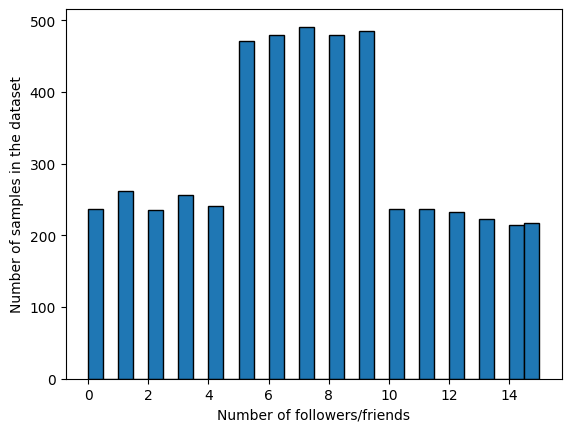

In [11]:
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt
df = pd.read_csv('personality_dataset.csv')

ax = df['Friends_circle_size'].plot(kind='hist', bins=30, edgecolor='black')
ax.set_xlabel('Number of followers/friends')
ax.set_ylabel('Number of samples in the dataset')

Remove the name column using `drop()` method

In [10]:
import pandas as pd
df = pd.read_csv('personality_dataset.csv')
print('\nORIGINAL DATA SET')
print(df.head())
df = df.drop('Personality', axis=1)
print('\nDATA SET AFTER REMOVING THE Personality COLUMN')
print(df.head())


DATA SET BEFORE DROPPING PERSONALITY
   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0                 3        Yes                        6              7   
1                 2         No                        8              6   
2                 1         No                        9              4   
3                 8         No                        0              0   
4                 5        Yes                        3              0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                   14               5   Extrovert  
1                        No                    7               8   Extrovert  
2                        No                    9               3   Extrovert  
3                       Yes                    9               3   Introvert  
4                        No                    2               6   Introvert  

NEW DATASET AFTER DROPPING PERSONALITY COL

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [13]:
import numpy as np
import pandas as pd
df = pd.read_csv('personality_dataset.csv')
X = df.drop('Personality', axis=1).values
print('Features (X) shape:', X.shape)
print(X[:5])

Features (X) shape: (5000, 7)
[[3 'Yes' 6 7 'No' 14 5]
 [2 'No' 8 6 'No' 7 8]
 [1 'No' 9 4 'No' 9 3]
 [8 'No' 0 0 'Yes' 9 3]
 [5 'Yes' 3 0 'No' 2 6]]


Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [14]:
y = df['Personality'].values
print('Labels (y) shape:', y.shape)
print(y[:5])

Labels (y) shape: (5000,)
['Extrovert' 'Extrovert' 'Extrovert' 'Introvert' 'Introvert']


Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('personality_dataset.csv')

# Preprocessing: Convert categorical features to numerical
df['Stage_fear'] = df['Stage_fear'].map({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes': 1, 'No': 0})

# Encode the target variable 'Personality'
le = LabelEncoder()
df['Personality'] = le.fit_transform(df['Personality'])

# Define X (features) and y (labels)
X = df.drop('Personality', axis=1).values
y = df['Personality'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Display the dimensions of each variables using `.shape()`

In [18]:
from sklearn.model_selection import train_test_split
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train shape: (4000,)
y_test shape: (1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [6]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5,p=2,metric='euclidean')

Train the model using the `.fit()`

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


df = pd.read_csv('personality_dataset.csv')

df['Stage_fear'] = df['Stage_fear'].map({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes': 1, 'No': 0})


le = LabelEncoder()
df['Personality'] = le.fit_transform(df['Personality'])


X = df.drop('Personality', axis=1)
y = df['Personality']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


numerical_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


knn = KNeighborsClassifier(n_neighbors=5,p=2,metric='euclidean')


knn.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean')

Test the model using the `.predict()`

In [25]:
# put your answer here

## E. Evaluate the model

Create a confusion matrix

In [26]:
# put your answer here

Display the accuracy

In [27]:
# put your answer here

Display the precision

In [28]:
# put your answer here

Display the recall

In [29]:
# put your answer here

Display the f1-score

In [30]:
c# put your answer here

NameError: name 'c' is not defined

## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [ ]:
# put your answer here